In [1]:
!pip install ultralytics seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00


In [17]:
import os
import cv2
import zipfile
import shutil

import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

from torchvision import models
from torchvision import transforms
from torchvision import datasets

from torch.utils.data import DataLoader

from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_curve,

    auc,

    precision_recall_curve
)

from sklearn.preprocessing import label_binarize

In [10]:
device = torch.device(

    "cuda" if torch.cuda.is_available()

    else "cpu"
)

print("Using Device:", device)

Using Device: cpu


In [12]:
zip_path = "/content/dataset.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    zip_ref.extractall(extract_path)

print("Dataset Extracted")

Dataset Extracted


In [13]:
print(os.listdir(extract_path))

['test', 'valid', 'train', 'data.yaml', 'README.roboflow.txt', 'README.dataset.txt']


In [18]:
classes = [

    "Flowering",

    "Germination",

    "Harvesting",

    "Vegetative"
]


In [19]:
classification_path = "/content/classification_dataset"

splits = ["train", "valid"]


for split in splits:

    for cls in classes:

        os.makedirs(

            f"{classification_path}/{split}/{cls}",

            exist_ok=True
        )


In [20]:
for split in splits:

    image_folder = f"{extract_path}/{split}/images"

    label_folder = f"{extract_path}/{split}/labels"

    images = os.listdir(image_folder)

    for image_name in images:

        image_path = os.path.join(
            image_folder,
            image_name
        )

        label_path = os.path.join(

            label_folder,

            image_name.replace(".jpg", ".txt")
        )

        if not os.path.exists(label_path):

            continue

        image = cv2.imread(image_path)

        height, width, _ = image.shape

        with open(label_path, "r") as f:

            lines = f.readlines()

        for idx, line in enumerate(lines):

            parts = line.strip().split()

            class_id = int(parts[0])

            x_center = float(parts[1]) * width

            y_center = float(parts[2]) * height

            box_width = float(parts[3]) * width

            box_height = float(parts[4]) * height

            x1 = int(x_center - box_width / 2)

            y1 = int(y_center - box_height / 2)

            x2 = int(x_center + box_width / 2)

            y2 = int(y_center + box_height / 2)

            crop = image[y1:y2, x1:x2]

            if crop.size == 0:

                continue

            class_name = classes[class_id]

            save_path = f"{classification_path}/{split}/{class_name}/{image_name[:-4]}_{idx}.jpg"

            cv2.imwrite(
                save_path,
                crop
            )

print("Classification Dataset Created")

Classification Dataset Created


In [21]:
print(os.listdir(classification_path))

['valid', 'train']


In [22]:

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()
])


# ============================================================
# VALIDATION DATASET
# ============================================================

valid_dataset = datasets.ImageFolder(

    root=f"{classification_path}/valid",

    transform=transform
)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=16,

    shuffle=False
)

print("Validation Dataset Loaded")

Validation Dataset Loaded


In [23]:
class CropCNN(nn.Module):

    def __init__(self):

        super(CropCNN, self).__init__()

        self.conv1 = nn.Conv2d(
            3,
            32,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            64,
            128,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            2,
            2
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(
            128 * 28 * 28,
            256
        )

        self.fc2 = nn.Linear(
            256,
            4
        )

    def forward(self, x):

        x = self.pool(
            self.relu(self.conv1(x))
        )

        x = self.pool(
            self.relu(self.conv2(x))
        )

        x = self.pool(
            self.relu(self.conv3(x))
        )

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.fc2(x)

        return x


# ============================================================
# LOAD CNN MODEL
# ============================================================

cnn_model = CropCNN().to(device)

cnn_model.load_state_dict(

    torch.load(
        "/content/crop_cnn_model.pth",
        map_location=device
    )
)

cnn_model.eval()

print("CNN Model Loaded")


# ============================================================
# LOAD RESNET MODEL
# ============================================================

resnet_model = models.resnet50(
    pretrained=False
)

num_features = resnet_model.fc.in_features

resnet_model.fc = nn.Sequential(

    nn.Linear(
        num_features,
        256
    ),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(
        256,
        4
    )
)

resnet_model.load_state_dict(

    torch.load(
        "/content/resnet_model.pth",
        map_location=device
    )
)

resnet_model = resnet_model.to(device)

resnet_model.eval()

print("ResNet50 Loaded")


CNN Model Loaded
ResNet50 Loaded


In [24]:
def evaluate_model(model, model_name):

    all_labels = []

    all_predictions = []

    all_probabilities = []

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    all_labels = np.array(all_labels)

    all_predictions = np.array(all_predictions)

    all_probabilities = np.array(all_probabilities)

    # ============================================================
    # METRICS
    # ============================================================

    accuracy = accuracy_score(

        all_labels,

        all_predictions
    )

    precision = precision_score(

        all_labels,

        all_predictions,

        average='weighted'
    )

    recall = recall_score(

        all_labels,

        all_predictions,

        average='weighted'
    )

    f1 = f1_score(

        all_labels,

        all_predictions,

        average='weighted'
    )

    print(f"\n========== {model_name} ==========")

    print(f"Accuracy: {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"F1 Score: {f1:.4f}")

    print("\nClassification Report:\n")

    print(

        classification_report(

            all_labels,

            all_predictions,

            target_names=classes
        )
    )

    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(

        all_labels,

        all_predictions
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues',

        xticklabels=classes,

        yticklabels=classes
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ============================================================
    # ROC CURVE
    # ============================================================

    labels_bin = label_binarize(

        all_labels,

        classes=[0,1,2,3]
    )

    plt.figure(figsize=(8,6))

    for i in range(4):

        fpr, tpr, _ = roc_curve(

            labels_bin[:,i],

            all_probabilities[:,i]
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(

            fpr,

            tpr,

            label=f"{classes[i]} (AUC={roc_auc:.2f})"
        )

    plt.plot([0,1],[0,1],'--')

    plt.title(f"{model_name} ROC Curve")

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.show()

    # ============================================================
    # PRECISION RECALL CURVE
    # ============================================================

    plt.figure(figsize=(8,6))

    for i in range(4):

        precision_curve, recall_curve, _ = precision_recall_curve(

            labels_bin[:,i],

            all_probabilities[:,i]
        )

        plt.plot(

            recall_curve,

            precision_curve,

            label=classes[i]
        )

    plt.title(f"{model_name} Precision Recall Curve")

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.legend()

    plt.show()

    return accuracy



========== Custom CNN ==========
Accuracy: 0.7206
Precision: 0.7177
Recall: 0.7206
F1 Score: 0.6945

Classification Report:

              precision    recall  f1-score   support

   Flowering       0.65      0.64      0.64       408
 Germination       0.75      0.98      0.85       365
  Harvesting       0.74      0.88      0.80       601
  Vegetative       0.72      0.29      0.42       369

    accuracy                           0.72      1743
   macro avg       0.72      0.70      0.68      1743
weighted avg       0.72      0.72      0.69      1743



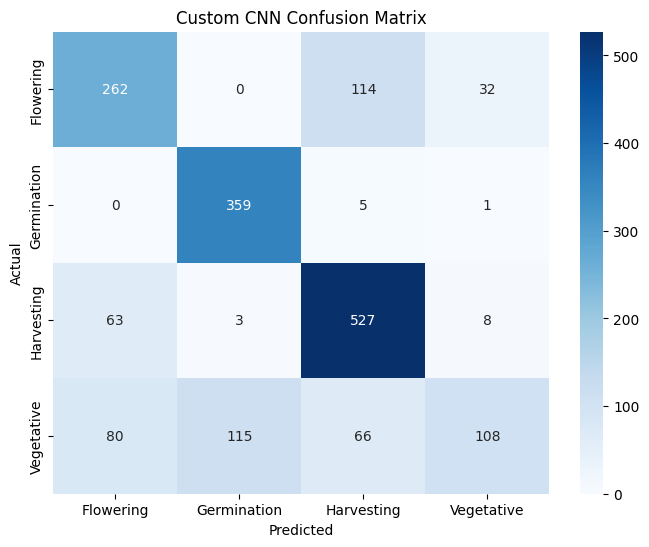

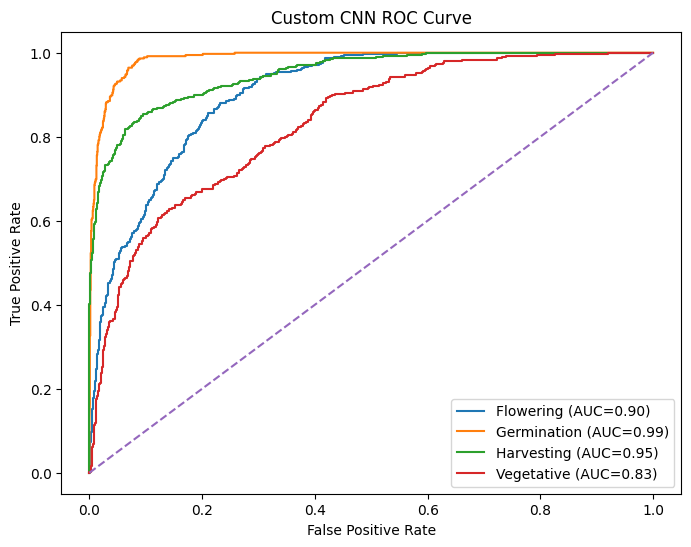

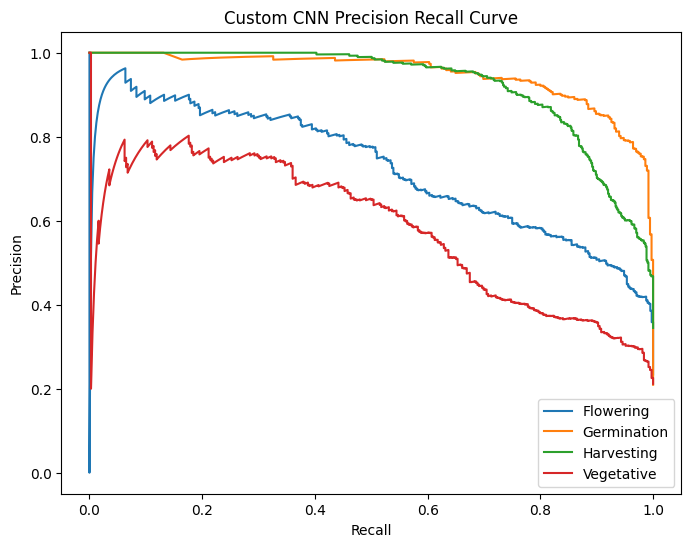

In [25]:
cnn_accuracy = evaluate_model(

    cnn_model,

    "Custom CNN"
)


========== ResNet50 ==========
Accuracy: 0.8026
Precision: 0.8158
Recall: 0.8026
F1 Score: 0.8049

Classification Report:

              precision    recall  f1-score   support

   Flowering       0.68      0.75      0.71       408
 Germination       0.83      0.93      0.88       365
  Harvesting       0.96      0.78      0.86       601
  Vegetative       0.72      0.77      0.75       369

    accuracy                           0.80      1743
   macro avg       0.80      0.81      0.80      1743
weighted avg       0.82      0.80      0.80      1743



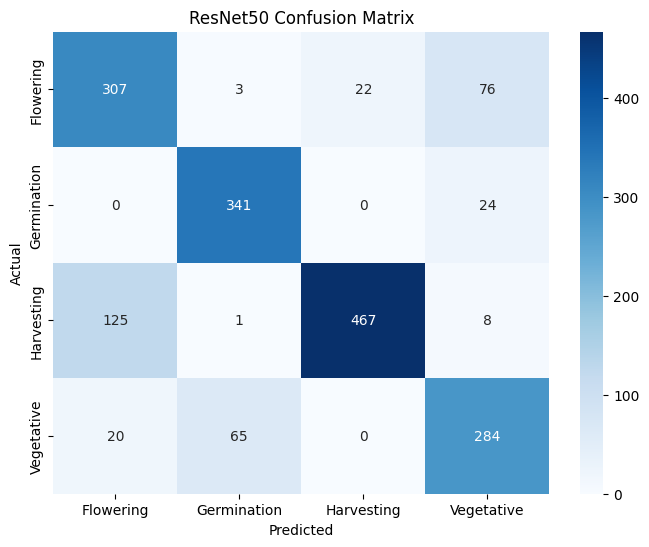

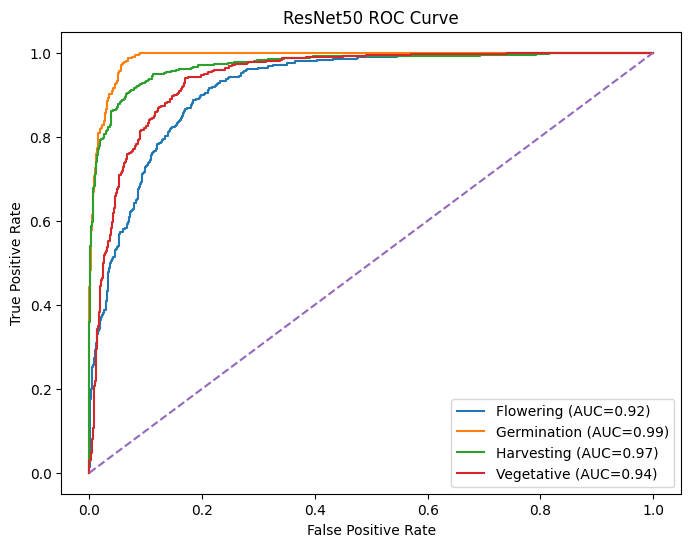

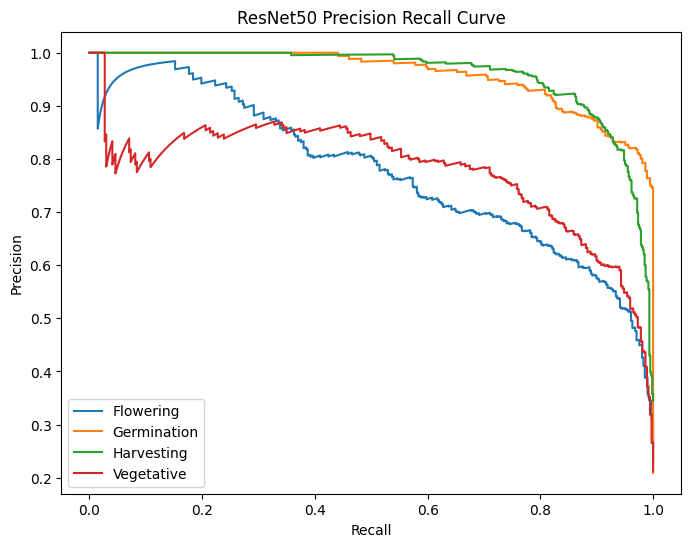

In [26]:
resnet_accuracy = evaluate_model(

    resnet_model,

    "ResNet50"
)

In [27]:
yaml_content = """

train: /content/dataset/train/images
val: /content/dataset/valid/images

nc: 4

names:
  0: Flowering
  1: Germination
  2: Harvesting
  3: Vegetative
"""

with open("data.yaml", "w") as f:

    f.write(yaml_content)

print("data.yaml created")

data.yaml created


In [28]:
yolo_model = YOLO(
    "/content/best.pt"
)

print("YOLO Model Loaded")

YOLO Model Loaded


In [29]:
metrics = yolo_model.val(
    data="data.yaml"
)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2337.8±812.2 MB/s, size: 51.4 KB)
val: Scanning /content/dataset/valid/labels... 1462 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1462/1462 3.0Kit/s 0.5s
val: New cache created: /content/dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 92/92 2.5s/it 3:50
                   all       1462       1743      0.972      0.964      0.985      0.724
             Flowering        366        408      0.984      0.973      0.992      0.787
           Germination        365        365      0.985      0.981      0.978      0.628
            Harvesting        365        601      0.925      0.909      0.976      0.709
            Vegetative        366        369      0.995      0.992      0.992      0.772
Spe

In [30]:
print("\n========== YOLOv8 ==========")

print("Precision:", metrics.box.mp)

print("Recall:", metrics.box.mr)

print("mAP50:", metrics.box.map50)

print("mAP50-95:", metrics.box.map)


========== YOLOv8 ==========
Precision: 0.9723596578737467
Recall: 0.9635599497409437
mAP50: 0.9847530411030752
mAP50-95: 0.7239877235729812


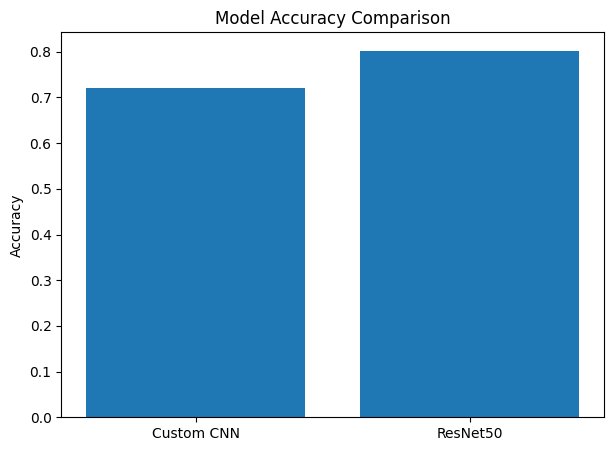

In [31]:
model_names = [

    "Custom CNN",

    "ResNet50"
]

accuracies = [

    cnn_accuracy,

    resnet_accuracy
]

plt.figure(figsize=(7,5))

plt.bar(

    model_names,

    accuracies
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()